# Aviation Weather Go/No-Go Decision — MDP + POMDP

**Can we find the mathematically optimal policy for a pilot deciding whether to continue or divert?**

This notebook solves that problem using a **Markov Decision Process (MDP)** solved with **value iteration** — then extends it to a **Partially Observable MDP (POMDP)** where the pilot can't directly see the weather, only noisy sensor readings.

Based on: Kochenderfer, Wheeler & Wray, *Algorithms for Decision Making*, Ch. 7 & 19–22 (MIT Press, 2022).

### Scenario
A pilot is flying from Phoenix (KPHX) to San Diego (KSAN) via two intermediate waypoints. At each waypoint, weather conditions are **good**, **marginal**, or **bad**. The pilot must decide: **continue** to the next waypoint, or **divert** to the nearest alternate airport.

---

### Outline
1. [MDP Formulation](#1-mdp-formulation) — states, actions, transitions, rewards
2. [Value Iteration](#2-value-iteration) — the Bellman backup and convergence
3. [Results](#3-results) — optimal value function and policy
4. [Visualizations](#4-visualizations) — heatmaps, convergence plot
5. [Simulations](#5-simulations) — sample flights under the optimal policy
6. [Interpretation](#6-interpretation) — what the policy tells us
7. [POMDP Extension](#7-pomdp-extension) — flying with imperfect sensors
8. [Sensitivity Analysis](#8-sensitivity-analysis) — how robust is the policy to reward choices?
9. [Belief Thresholds](#9-belief-thresholds) — where does the POMDP policy flip on the simplex?

## 1. MDP Formulation

An MDP is defined by the tuple **(S, A, T, R, γ)**:

| Component | Symbol | Description |
|-----------|--------|-------------|
| State space | **S** | All possible situations the pilot can be in |
| Action space | **A** | Choices available at each state |
| Transition function | **T(s'\|s,a)** | Probability of reaching s' from s after action a |
| Reward function | **R(s,a)** | Immediate reward for taking action a in state s |
| Discount factor | **γ** | How much future rewards are worth relative to immediate rewards |

The **Markov assumption**: the next state depends only on the current state and action — not on how you got there. This is realistic for our problem; the weather ahead depends on current conditions, not flight history.


In [1]:
from scenario import (
    WAYPOINT_NAMES, WEATHER_CONDITIONS, ACTIONS,
    DISCOUNT_FACTOR, WEATHER_TRANSITION,
    REWARD_ARRIVE, REWARD_DIVERT, WEATHER_CONTINUE_REWARDS,
)
from mdp import build_states, transition, reward
import numpy as np

states = build_states()

print("STATE SPACE")
print("-" * 40)
for s in states:
    print(f"  {s}")

print(f"\nTotal states: {len(states)}")
print(f"  In-flight: {sum(1 for s in states if isinstance(s, tuple))}")
print(f"  Terminal:  2 (arrived, diverted)")


STATE SPACE
----------------------------------------
  (0, 0)
  (0, 1)
  (0, 2)
  (1, 0)
  (1, 1)
  (1, 2)
  (2, 0)
  (2, 1)
  (2, 2)
  (3, 0)
  (3, 1)
  (3, 2)
  arrived
  diverted

Total states: 14
  In-flight: 12
  Terminal:  2 (arrived, diverted)


### Weather transition probabilities

When a pilot continues to the next waypoint, weather evolves according to this matrix.
Each row is the current weather; each column is the probability of the next weather state.


In [2]:
import pandas as pd

df = pd.DataFrame(
    WEATHER_TRANSITION,
    index=[f'from {w}' for w in WEATHER_CONDITIONS],
    columns=[f'to {w}' for w in WEATHER_CONDITIONS],
)
print("Weather Transition Matrix T_weather[current, next]")
print(df.to_string())
print()
print("Note: weather tends to persist (diagonal is highest),")
print("but bad weather is especially sticky (0.70 chance of staying bad).")


Weather Transition Matrix T_weather[current, next]
               to good  to marginal  to bad
from good         0.70         0.25    0.05
from marginal     0.30         0.40    0.30
from bad          0.05         0.25    0.70

Note: weather tends to persist (diagonal is highest),
but bad weather is especially sticky (0.70 chance of staying bad).


### Reward structure

| Situation | Reward |
|-----------|--------|
| Arrive at destination | +100 |
| Divert to alternate | -20 |
| Continue in good weather | +2 |
| Continue in marginal weather | -5 |
| Continue in bad weather | -80 |

The large penalty for flying in bad weather (-80) creates tension with the divert penalty (-20). The optimal policy must weigh: *how much bad weather am I likely to fly through if I continue, and is it worth the risk?*


In [3]:
# Verify the reward function on a few states
test_cases = [
    ((0, 0), 0, "KPHX, good, continue"),
    ((0, 2), 0, "KPHX, bad, continue"),
    ((0, 2), 1, "KPHX, bad, divert"),
    ((3, 2), 0, "KSAN, bad, continue (last waypoint — arrival!)"),
]

print(f"{'State + Action':<45} {'Reward':>8}")
print("-" * 55)
for s, a, label in test_cases:
    r = reward(s, a)
    print(f"{label:<45} {r:>8.1f}")


State + Action                                  Reward
-------------------------------------------------------
KPHX, good, continue                               2.0
KPHX, bad, continue                              -80.0
KPHX, bad, divert                                -20.0
KSAN, bad, continue (last waypoint — arrival!)     20.0


## 2. Value Iteration

### The Bellman backup

Value iteration repeatedly applies the **Bellman backup** to every state until the value function converges:

$$U_{k+1}(s) = \max_a \left[ R(s,a) + \gamma \sum_{s'} T(s'|s,a)\, U_k(s') \right]$$

The inner expression — $R(s,a) + \gamma \sum_{s'} T(s'|s,a)\, U_k(s')$ — is the **Q-value** $Q(s,a)$: the expected return from taking action $a$ in state $s$ and then following the optimal policy.

Taking the max over actions gives the best possible value for state $s$.

### Why it converges

The Bellman backup is a **contraction mapping** — each application brings the value function strictly closer to $U^*$. The algorithm stops when the **Bellman residual** $\|U_{k+1} - U_k\|_\infty$ falls below a tolerance threshold.


In [4]:
from value_iteration import value_iteration

U, policy, residuals = value_iteration(
    states=states,
    transition_fn=transition,
    reward_fn=reward,
    gamma=DISCOUNT_FACTOR,
    max_iterations=500,
    tolerance=1e-6,
)

print(f"Iterations to convergence: {len(residuals)}")
print(f"Final Bellman residual:    {residuals[-1]:.2e}")


Converged in 5 iterations (residual=0.00e+00)
Iterations to convergence: 5
Final Bellman residual:    0.00e+00


## 3. Results

### Optimal value function U*(s)

$U^*(s)$ is the maximum expected discounted reward achievable from state $s$ under the optimal policy.


In [5]:
print(f"{'State':<28} {'π*(s)':<12} {'U*(s)':>8}")
print("-" * 52)
for i, s in enumerate(states):
    if isinstance(s, tuple):
        wp, w = s
        label = f"({WAYPOINT_NAMES[wp]}, {WEATHER_CONDITIONS[w]})"
        act   = ACTIONS[policy[s]]
        print(f"{label:<28} {act:<12} {U[i]:>8.2f}")


State                        π*(s)           U*(s)
----------------------------------------------------
(KPHX, good)                 continue        63.15
(KPHX, marginal)             continue        27.30
(KPHX, bad)                  divert         -20.00
(KBXK, good)                 continue        78.77
(KBXK, marginal)             continue        40.93
(KBXK, bad)                  divert         -20.00
(KTRM, good)                 continue        93.34
(KTRM, marginal)             continue        65.87
(KTRM, bad)                  divert         -20.00
(KSAN, good)                 continue       102.00
(KSAN, marginal)             continue        95.00
(KSAN, bad)                  continue        20.00


### Key observations

- **Value increases as you approach the destination** — more of the route is behind you
- **Bad weather tanks the value** at every waypoint except the last (KSAN)
- **At KSAN in bad weather**, the optimal action is still *continue* — you're at the final waypoint, so arrival (+100) plus the bad weather penalty (-80) = +20, which beats diverting (-20)
- **Marginal weather** — the policy continues through marginal weather at every waypoint because weather might improve and arrival reward is large enough to justify the risk


## 4. Visualizations

Saved: plots/value_function.png


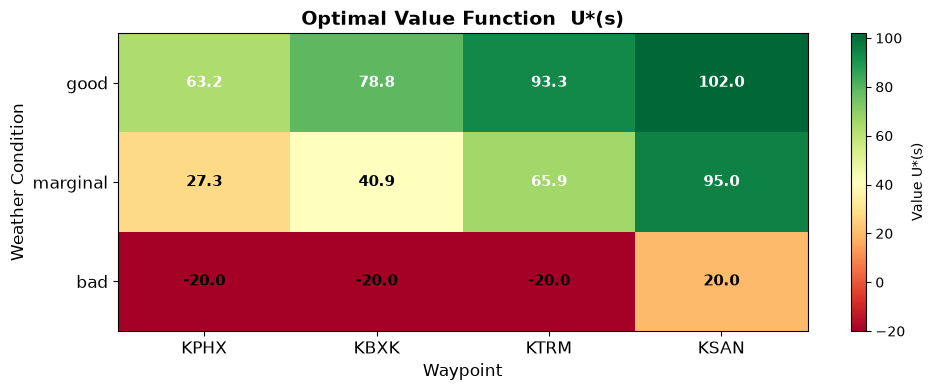

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
from visualize import plot_value_function, plot_policy, plot_convergence

plot_value_function(states, U, save_path='plots/value_function.png')
plt.show()


Saved: plots/policy_map.png


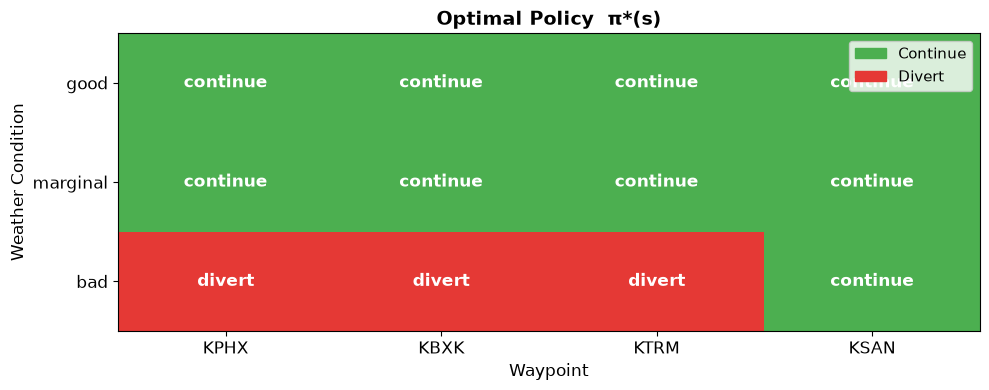

In [7]:
plot_policy(states, policy, save_path='plots/policy_map.png')
plt.show()

Saved: plots/convergence.png


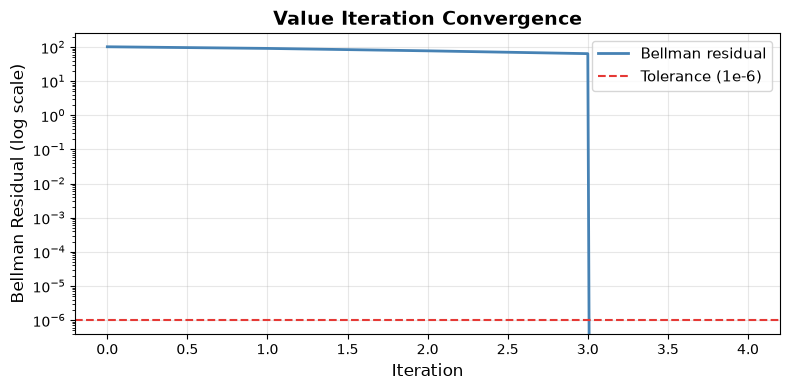

In [8]:
plot_convergence(residuals, save_path='plots/convergence.png')
plt.show()

## 5. Simulations

Three simulated flights — one starting in each weather condition — using the optimal policy.
Weather evolves stochastically between waypoints.


Starting weather: good
  KPHX          weather=good        → continue
  KBXK          weather=marginal    → continue
  KTRM          weather=marginal    → continue
  KSAN          weather=bad         → continue
  ARRIVED       weather=bad         → success
Saved: plots/simulation_good.png


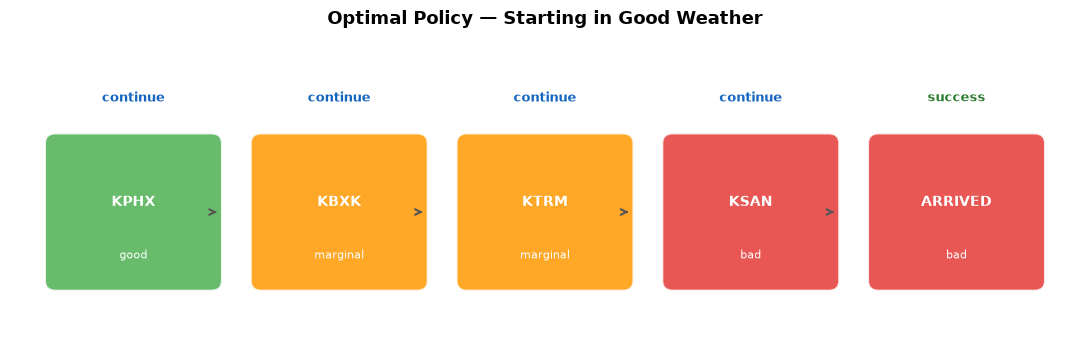


Starting weather: marginal
  KPHX          weather=marginal    → continue
  KBXK          weather=bad         → divert
  ALTERNATE     weather=—           → diverted
Saved: plots/simulation_marginal.png


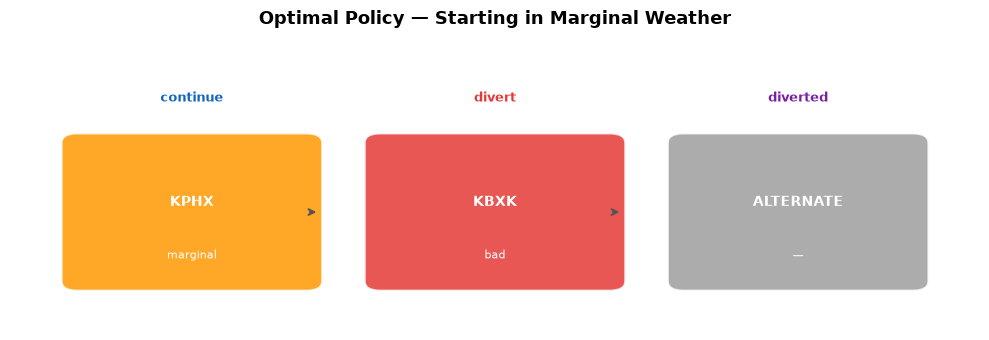


Starting weather: bad
  KPHX          weather=bad         → divert
  ALTERNATE     weather=—           → diverted


Saved: plots/simulation_bad.png


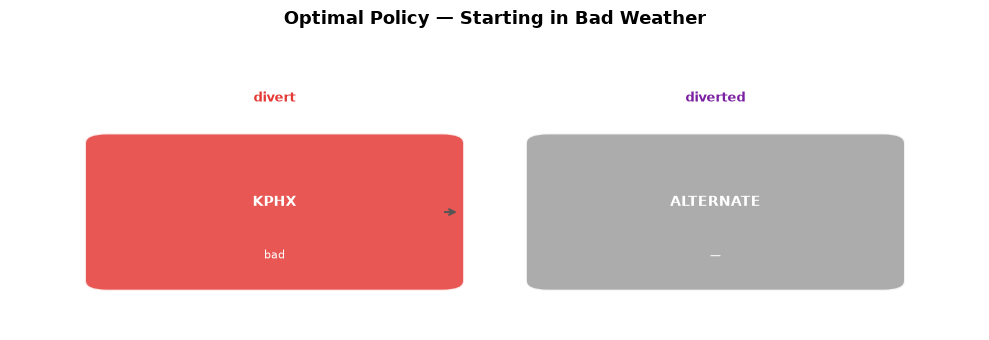

In [9]:
from visualize import simulate_flight, plot_simulation

for w_idx, w_name in enumerate(WEATHER_CONDITIONS):
    traj = simulate_flight(states, policy, initial_weather=w_idx, seed=42)
    print(f"Starting weather: {w_name}")
    for step in traj:
        print(f"  {step['waypoint']:<12}  weather={step['weather']:<10}  → {step['action']}")
    plot_simulation(
        traj,
        title=f'Optimal Policy — Starting in {w_name.capitalize()} Weather',
        save_path=f'plots/simulation_{w_name}.png',
    )
    plt.show()
    print()


## 6. Interpretation

### What the optimal policy tells us

The MDP formalizes a question every pilot faces: *at what point does the expected cost of continuing outweigh the expected cost of diverting?*

The value iteration solution reveals several non-obvious insights:

1. **Divert early or not at all (in bad weather).** Bad weather at KPHX or KBXK triggers an immediate divert — you'd have to fly through too many bad-weather legs. But at KTRM or KSAN, the remaining route is short enough that continuing is worth it.

2. **Marginal weather is always worth pushing through** (in this model). The expected value of continuing — weighted by the 30% chance that weather improves — is high enough that the policy never diverts in marginal conditions. This would change if the weather transition matrix were more pessimistic.

3. **The discount factor matters.** With γ = 0.95, future rewards are still heavily weighted. A pilot who heavily discounts the future (impatient, fatigued) would optimally divert sooner.

### Extensions

This is a simplified MDP. Real go/no-go decisions involve:
- Fuel state as part of the state space
- Pilot fatigue and workload
- More granular weather (not just 3 bins)
- Continuous state spaces (→ approximate methods from Ch. 8–9)
- Multiple aircraft / ATC coordination (→ multiagent MDPs from Ch. 24–27)

Each of these is a direct extension of the framework implemented here.

---

*Based on Kochenderfer, Wheeler & Wray, Algorithms for Decision Making, Ch. 7 (MIT Press, 2022).*


---

## 7. POMDP Extension — Flying with Imperfect Sensors

### The new problem

In the MDP above, the pilot **directly observes** true weather at each waypoint. In reality, weather reports are noisy: a METAR might be outdated, radar can be ambiguous, and different sensors disagree.

This section extends the problem to a **Partially Observable MDP (POMDP)**, where the pilot receives two noisy sensor readings instead of the true weather:

1. **METAR category** — a categorical reading (good / marginal / bad) that can be wrong
2. **Confidence score** — binary (high / low), indicating how much the sensors agree

The pilot must now reason about their **belief state** — a probability distribution over possible weather conditions — and update it with each new observation using Bayes' rule.

### The math

The POMDP adds an observation space **O** and observation model **O(o | s')** to the MDP tuple:

$$b'(s') = \frac{O(o \mid s') \sum_s T(s'\mid s, a)\, b(s)}{P(o \mid b, a)}$$

The value function is now defined over **beliefs** rather than states:

$$V^*(b) = \max_a \left[ \sum_s b(s) R(s,a) + \gamma \sum_o P(o \mid b,a)\, V^*(\tau(b,a,o)) \right]$$

Because the pilot always knows which waypoint they are at (waypoints are fully observable), the problem decomposes into independent POMDP stages — one per waypoint — solved by **backward induction**.

Each stage's value function is convex and piecewise-linear in belief, represented as a set of **alpha vectors**: $V_{wp}(b) = \max_{\alpha \in \Gamma_{wp}} b \cdot \alpha$

### Observation model

In [10]:
from pomdp import OBS_CATEGORY, P_HIGH_CONF, OBS_MODEL, OBS_LABELS, N_OBS
import numpy as np
import pandas as pd

print("METAR category sensor  P(reported_category | true_weather)")
df_cat = pd.DataFrame(
    OBS_CATEGORY,
    index=[f'true {w}' for w in WEATHER_CONDITIONS],
    columns=['reported good', 'reported marginal', 'reported bad'],
)
print(df_cat.to_string())

print()
print("Confidence sensor  P(high_confidence | true_weather):")
for i, w in enumerate(WEATHER_CONDITIONS):
    print(f"  true {w:<10}  P(high) = {P_HIGH_CONF[i]:.2f}")

print()
print("Full observation model  P(observation | true_weather):")
df_obs = pd.DataFrame(
    OBS_MODEL,
    index=[f'true {w}' for w in WEATHER_CONDITIONS],
    columns=OBS_LABELS,
)
print(df_obs.round(3).to_string())
print()
print("Each row sums to:", OBS_MODEL.sum(axis=1).round(6))

METAR category sensor  P(reported_category | true_weather)
               reported good  reported marginal  reported bad
true good               0.70               0.25          0.05
true marginal           0.20               0.60          0.20
true bad                0.05               0.25          0.70

Confidence sensor  P(high_confidence | true_weather):
  true good        P(high) = 0.85
  true marginal    P(high) = 0.40
  true bad         P(high) = 0.80

Full observation model  P(observation | true_weather):
               good / low-conf  good / high-conf  marginal / low-conf  marginal / high-conf  bad / low-conf  bad / high-conf
true good                0.105             0.595                0.038                 0.212           0.008            0.042
true marginal            0.120             0.080                0.360                 0.240           0.120            0.080
true bad                 0.010             0.040                0.050                 0.200           0.1

### Belief update

At each waypoint, the pilot maintains a **belief** — a probability distribution over weather states. After observing $o$, the belief updates in two steps:

1. **Prediction**: propagate the prior belief through the weather transition model
   $$b_{\text{pred}}(w') = \sum_w T(w'|w)\, b(w)$$

2. **Update**: reweight by the likelihood of the observation
   $$b'(w') \propto O(o \mid w')\, b_{\text{pred}}(w')$$

In [11]:
from pomdp import predict_belief, belief_update

# Example: pilot starts with uniform belief, observes "bad / high-confidence"
b_prior = np.array([1/3, 1/3, 1/3])
b_pred  = predict_belief(b_prior)
b_after = belief_update(b_pred, obs_idx=5)  # obs 5 = bad / high-conf

print("Belief update example: observe 'bad / high-confidence'")
print()
print(f"  Prior belief:      good={b_prior[0]:.3f}  marginal={b_prior[1]:.3f}  bad={b_prior[2]:.3f}")
print(f"  Predicted belief:  good={b_pred[0]:.3f}  marginal={b_pred[1]:.3f}  bad={b_pred[2]:.3f}")
print(f"  Updated belief:    good={b_after[0]:.3f}  marginal={b_after[1]:.3f}  bad={b_after[2]:.3f}")
print()
print("A single 'bad / high-conf' reading shifts P(bad) from 0.35 → {:.2f}".format(b_after[2]))

Belief update example: observe 'bad / high-confidence'

  Prior belief:      good=0.333  marginal=0.333  bad=0.333
  Predicted belief:  good=0.350  marginal=0.300  bad=0.350
  Updated belief:    good=0.063  marginal=0.102  bad=0.834

A single 'bad / high-conf' reading shifts P(bad) from 0.35 → 0.83


### Solving the POMDP

Because waypoints are fully observable, we solve one POMDP stage per waypoint working **backwards from KSAN to KPHX**.

At each stage, we compute alpha vectors using a **PBVI-style backup** (Point-Based Value Iteration):
- Sample ~400 belief points from the simplex
- For each belief point, find the best combination of next-stage alpha vectors (one per observation)
- Collect unique combinations → set of alpha vectors for this stage

In [12]:
from pomdp_solver import solve_pomdp, get_action

print("Solving POMDP by backward induction...")
gamma_per_wp = solve_pomdp()
print()
print("Alpha vectors encode the value function at each waypoint.")
print("More alpha vectors = more complex belief-dependent decisions.")

Solving POMDP by backward induction...
  KSAN: 2 alpha vectors
  KTRM: 2 alpha vectors
  KBXK: 3 alpha vectors
  KPHX: 7 alpha vectors

Alpha vectors encode the value function at each waypoint.
More alpha vectors = more complex belief-dependent decisions.


### POMDP policy at representative beliefs

In [13]:
from scenario import WAYPOINT_NAMES as WP, ACTIONS

key_beliefs = [
    (np.array([1.0, 0.0, 0.0]), "certain good"),
    (np.array([0.0, 1.0, 0.0]), "certain marginal"),
    (np.array([0.0, 0.0, 1.0]), "certain bad"),
    (np.array([1/3, 1/3, 1/3]), "uniform"),
    (np.array([0.6, 0.3, 0.1]), "likely good"),
    (np.array([0.1, 0.3, 0.6]), "likely bad"),
]

print(f"{'Waypoint':<8}  {'Belief (G/M/B)':<24}  {'Scenario':<18}  {'Action':<10}  {'V(b)':>7}  {'Q(cont)':>8}  {'Q(div)':>7}")
print("-" * 90)
for wp, wp_name in enumerate(WP):
    for b, label in key_beliefs:
        a, v, qc, qd = get_action(b, gamma_per_wp[wp])
        bstr = f"({b[0]:.2f}/{b[1]:.2f}/{b[2]:.2f})"
        print(f"{wp_name:<8}  {bstr:<24}  {label:<18}  {ACTIONS[a]:<10}  {v:>7.2f}  {qc:>8.2f}  {qd:>7.2f}")
    print()

Waypoint  Belief (G/M/B)            Scenario            Action         V(b)   Q(cont)   Q(div)
------------------------------------------------------------------------------------------
KPHX      (1.00/0.00/0.00)          certain good        continue      58.09     58.09   -20.00
KPHX      (0.00/1.00/0.00)          certain marginal    continue      13.96     13.96   -20.00
KPHX      (0.00/0.00/1.00)          certain bad         divert       -20.00    -92.50   -20.00
KPHX      (0.33/0.33/0.33)          uniform             continue      -9.71     -9.71   -20.00
KPHX      (0.60/0.30/0.10)          likely good         continue      27.67     27.67   -20.00
KPHX      (0.10/0.30/0.60)          likely bad          divert       -20.00    -48.48   -20.00

KBXK      (1.00/0.00/0.00)          certain good        continue      77.85     77.85   -20.00
KBXK      (0.00/1.00/0.00)          certain marginal    continue      35.43     35.43   -20.00
KBXK      (0.00/0.00/1.00)          certain bad      

### Key insight: uncertainty itself is a reason to divert

Compare the MDP and POMDP at KPHX:

- **MDP** (perfect observation): diverts only on *certain* bad weather
- **POMDP**: diverts at "likely bad" belief (60% bad) even though the pilot isn't certain

The POMDP pilot acts on their full belief distribution. A 60% probability of bad weather at the first waypoint means flying 3 more legs through a weather state that has a 70% chance of *staying* bad. The math says: don't take that risk.

In [14]:
# Side-by-side comparison: MDP vs POMDP at KPHX
print("KPHX policy — MDP (certain weather) vs POMDP (belief state)")
print()
print(f"{'Weather/Belief':<30}  {'MDP action':<12}  {'MDP value':>9}  {'POMDP action':<14}  {'POMDP V(b)':>10}")
print("-" * 82)

mdp_states = [(0,0,'certain good'),(0,1,'certain marginal'),(0,2,'certain bad')]
pomdp_beliefs = [
    (np.array([1.,0.,0.]),'certain good'),
    (np.array([0.,1.,0.]),'certain marginal'),
    (np.array([0.,0.,1.]),'certain bad'),
]

for (wp_idx,w_idx,lbl), (b,_) in zip(mdp_states, pomdp_beliefs):
    s = (wp_idx, w_idx)
    mdp_act  = ACTIONS[policy[s]]
    mdp_val  = U[states.index(s)]
    p_a, p_v, *_ = get_action(b, gamma_per_wp[0])
    pomdp_act = ACTIONS[p_a]
    print(f"{lbl:<30}  {mdp_act:<12}  {mdp_val:>9.2f}  {pomdp_act:<14}  {p_v:>10.2f}")

print()
# Now show a belief the MDP can't represent
b_mixed = np.array([0.1, 0.3, 0.6])
p_a, p_v, qc, qd = get_action(b_mixed, gamma_per_wp[0])
print(f"{'likely bad (0.1/0.3/0.6)':<30}  {'N/A':<12}  {'N/A':>9}  {ACTIONS[p_a]:<14}  {p_v:>10.2f}")
print()
print("The POMDP can divert at beliefs the MDP has no representation for.")

KPHX policy — MDP (certain weather) vs POMDP (belief state)

Weather/Belief                  MDP action    MDP value  POMDP action    POMDP V(b)
----------------------------------------------------------------------------------
certain good                    continue          63.15  continue             58.09
certain marginal                continue          27.30  continue             13.96
certain bad                     divert           -20.00  divert              -20.00

likely bad (0.1/0.3/0.6)        N/A                 N/A  divert              -20.00

The POMDP can divert at beliefs the MDP has no representation for.


### Simulated flights under the POMDP policy

In [15]:
from pomdp_solver import simulate_pomdp

for w_idx, w_name in enumerate(WEATHER_CONDITIONS):
    print(f"True starting weather: {w_name}")
    traj = simulate_pomdp(gamma_per_wp, initial_weather=w_idx, seed=42)
    for step in traj:
        if step['belief'] is not None:
            b = step['belief']
            bstr = f"b=({b[0]:.2f}/{b[1]:.2f}/{b[2]:.2f})"
        else:
            bstr = ""
        print(f"  {step['waypoint']:<12}  true={step['true_weather']:<10}  "
              f"obs={step['obs']:<25}  {bstr:<28}  → {step['action']}")
    print()

True starting weather: good
  KPHX          true=good        obs=marginal / high-conf       b=(0.33/0.37/0.31)            → continue
  KBXK          true=good        obs=marginal / high-conf       b=(0.35/0.34/0.31)            → continue
  KTRM          true=good        obs=good / low-conf            b=(0.49/0.47/0.04)            → continue
  KSAN          true=bad         obs=bad / high-conf            b=(0.13/0.16/0.70)            → continue
  ARRIVED       true=bad         obs=—                                                        → success

True starting weather: marginal
  KPHX          true=marginal    obs=marginal / high-conf       b=(0.33/0.37/0.31)            → continue
  KBXK          true=marginal    obs=bad / low-conf             b=(0.03/0.42/0.55)            → divert
  ALTERNATE     true=—           obs=—                                                        → diverted

True starting weather: bad
  KPHX          true=bad         obs=bad / high-conf            b=(0.06/0.

### What to explore next

- **Change the observation accuracy**: make `OBS_CATEGORY` closer to the identity matrix (perfect sensors) and the POMDP policy should converge toward the MDP policy
- **Change the confidence sensor**: set `P_HIGH_CONF = [0.5, 0.5, 0.5]` (sensors never agree) and watch uncertainty grow
- **Add fuel as a state variable**: the state becomes `(waypoint, weather, fuel_level)` — a direct extension of `scenario.py`
- **SARSOP**: replace the PBVI solver with SARSOP for tighter alpha vector bounds on larger problems

---

*POMDP formulation follows Kochenderfer, Wheeler & Wray, Algorithms for Decision Making, Ch. 19–22 (MIT Press, 2022).*

---

## 8. Sensitivity Analysis

The reward values (+100 arrive, −20 divert, −80 bad weather) aren't ground truth — they're modeling choices. How much does the policy depend on them?

Two sweeps:
1. **Divert penalty** from −5 to −100 — as diverting becomes more costly, does the pilot push through worse weather?
2. **Bad-weather continue cost** from −20 to −150 — as flying in bad weather becomes more dangerous, do more states flip to divert?

The heatmaps show the policy across all states; the line plots show exactly where individual states flip.

Saved: plots/sensitivity_divert.png


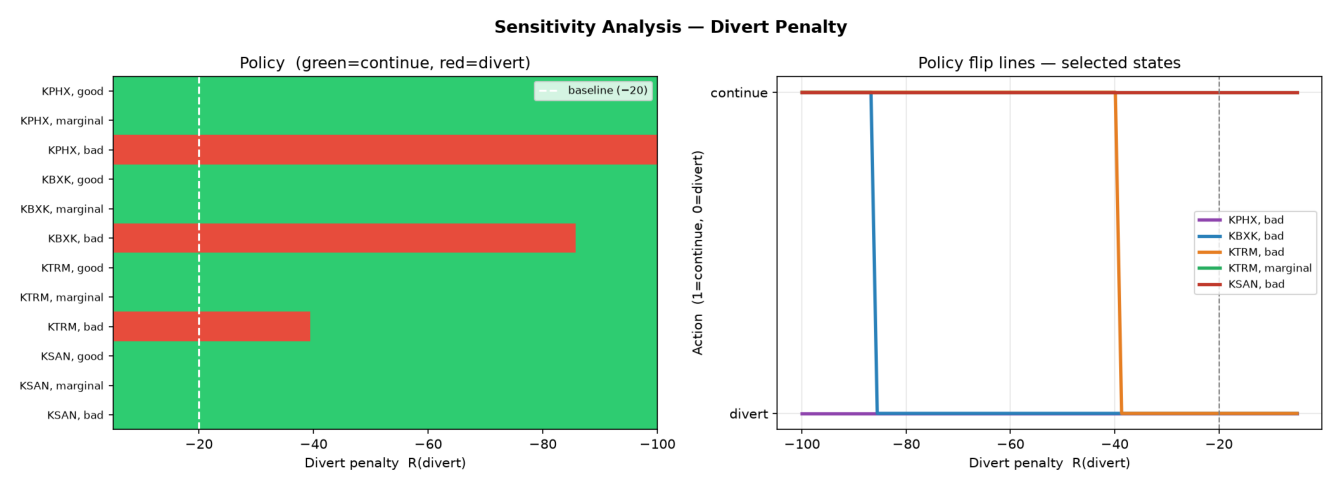

In [16]:
%matplotlib inline
from analysis import sensitivity_divert_penalty, sensitivity_bad_weather_cost
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sensitivity_divert_penalty()
img = mpimg.imread('plots/sensitivity_divert.png')
plt.figure(figsize=(14, 5)); plt.imshow(img); plt.axis('off'); plt.tight_layout(); plt.show()

### Reading the divert-penalty sweep

- Most states are **rock-solid** — the same action holds across the entire penalty range
- **KSAN bad weather** is the most sensitive state: it flips from divert → continue right around −20, which is exactly the baseline. Arrival (+100) minus bad-weather cost (−80) = +20, which only beats diverting when the divert penalty is worse than −20. The baseline sits right at the crossover.
- **KTRM and KBXK bad weather** flip at much softer penalties — the multi-leg risk makes diverting attractive even when it's cheap

Saved: plots/sensitivity_bad_cost.png


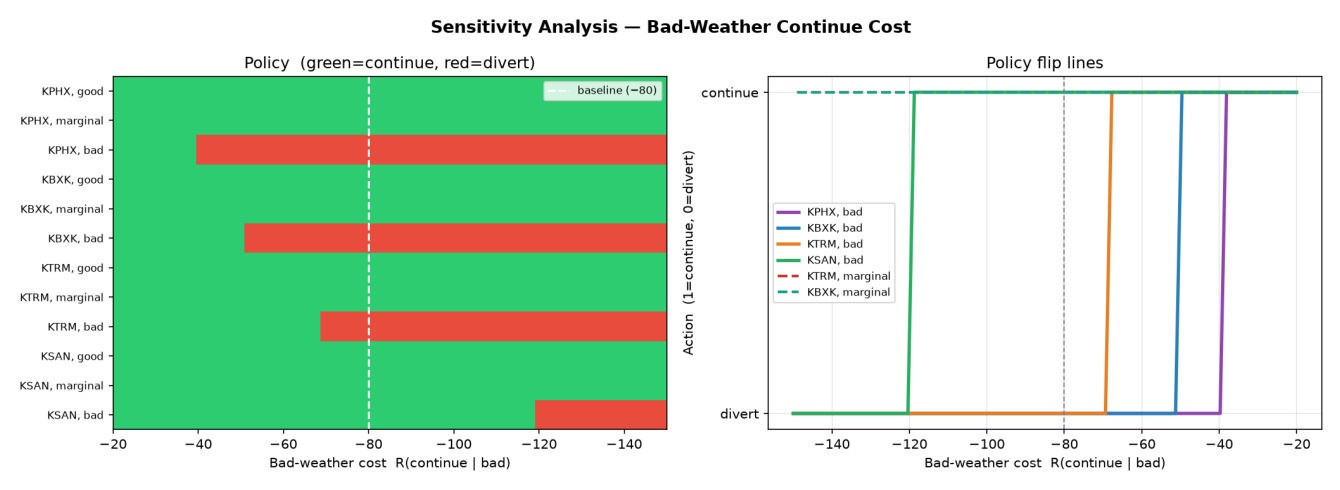

In [17]:
sensitivity_bad_weather_cost()
img = mpimg.imread('plots/sensitivity_bad_cost.png')
plt.figure(figsize=(14, 5)); plt.imshow(img); plt.axis('off'); plt.tight_layout(); plt.show()

### Reading the bad-weather cost sweep

- **KSAN bad weather** flips back to divert at around −100: once flying through bad weather costs as much as arrival earns (+100 − 100 = 0 < −20), diverting wins
- **Earlier waypoints** (KPHX, KBXK, KTRM) flip much earlier — around −35 to −50 — because bad weather at these points means flying through multiple subsequent legs, compounding the cost
- **Marginal-weather states** (dashed lines) are completely flat — bad-weather cost doesn't affect them. Their decision hinges on the 30% chance weather degrades, not the direct continue reward

**Takeaway:** the policy is most sensitive at KSAN in bad weather, and most robust at marginal-weather states. The choices that look non-obvious in the results table (KSAN bad = continue, marginal everywhere = continue) are actually the *stable* ones.

---

## 9. Belief Thresholds

In the MDP, the policy is a lookup table: one action per (waypoint, weather) state. In the POMDP, the policy is a function over the entire **belief simplex** — a continuous space of probability distributions.

The plot below maps each waypoint's simplex: every point is a possible belief (G/M/B probability), colored by the optimal action. The boundary between green and red is the **decision threshold** — the exact belief at which the pilot should switch from continue to divert.

This is the geometric interpretation of the alpha vector solution: each alpha vector carves out a region of belief space where it dominates.

Solving POMDP for threshold plot...
  KSAN: 2 alpha vectors
  KTRM: 2 alpha vectors
  KBXK: 3 alpha vectors
  KPHX: 7 alpha vectors


Saved: plots/belief_thresholds.png


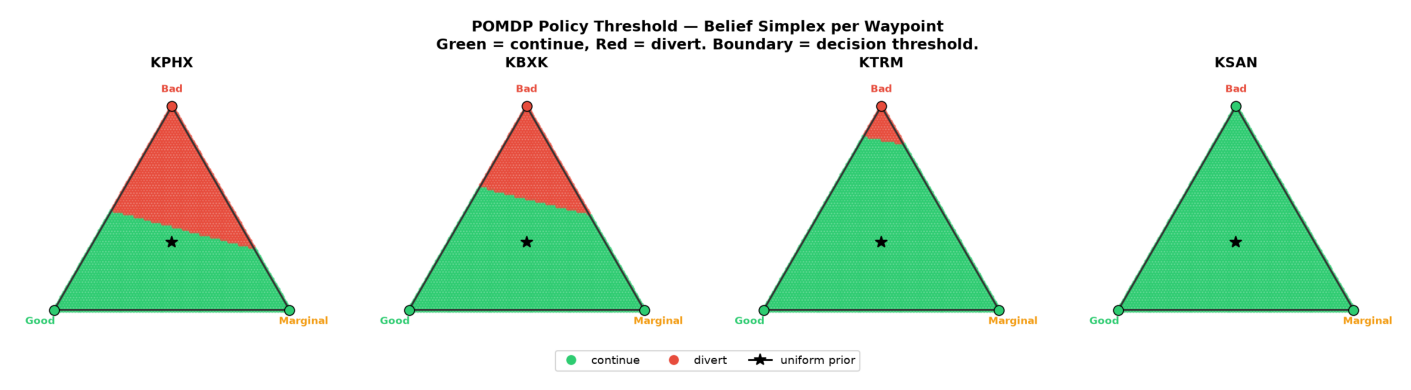

In [18]:
from analysis import plot_belief_thresholds

plot_belief_thresholds()
img = mpimg.imread('plots/belief_thresholds.png')
plt.figure(figsize=(16, 4)); plt.imshow(img); plt.axis('off'); plt.tight_layout(); plt.show()

### Reading the simplex maps

- **KSAN**: nearly the entire simplex is green — even a strong bad-weather belief doesn't trigger a divert this close to destination. The red zone only appears at extreme bad-weather beliefs (top corner).
- **KPHX**: the largest red region. High uncertainty about bad weather early in the route is a strong divert signal — you're committing to three more legs.
- **KBXK**: a clean straight-line boundary cutting across the simplex — this is the fingerprint of exactly **two alpha vectors** (one per action). The boundary is linear because $V^*(b) = \max_\alpha b \cdot \alpha$ is piecewise linear, and with two vectors it's just one line.
- **KTRM**: also a linear boundary, shifted toward the Bad corner compared to KPHX — you tolerate more bad-weather belief here because KSAN is one leg away.

The ★ (uniform prior) sits in the green zone at every waypoint — consistent with the earlier result that "when you don't know, keep going" holds everywhere on this route.

---

*Sections 8–9 demonstrate that the policies derived above are not artifacts of specific reward choices, and that the POMDP solution has a clean geometric structure interpretable directly from the alpha vectors.*